# MID evaluation

Load a trained checkpoint and report Best-of-20 ADE/FDE on the test split of a single scene.

## Configuration

fetching the checkpointed models. 

In [8]:
SCENE = "eth"            # which scene's test/val split to evaluate
SPLIT = "test"           # "test" or "val"
CHECKPOINT = f"../checkpoints/mid_loo_{SCENE}.pt"

BATCH_SIZE = 256
NUM_SAMPLES = 20         # K in Best-of-K (paper uses 20)
SAMPLING = "ddim"        # "ddpm" or "ddim"
STEP = 1                 # reverse-process stride. 1 = full diffusion chain.

# Paper convention: only evaluate pedestrians with the full 8-step history
# (current + 7 past). Setting this to 1 matches training's looser filter.
MIN_HISTORY = 7

# The ETH test set was scaled by 0.6 during preprocessing (a known quirk of
# the ETH/UCY benchmark). The literature reports numbers in the unscaled frame,
# so we divide ADE/FDE by 0.6 to match.
ETH_RESCALE = (SCENE == "eth" and SPLIT == "test")

SEED = 123

## Setup: paths, device, seeds

In [9]:
import os
import sys
import random
import numpy as np
import torch

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")
print(f"Device: {DEVICE}")

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

Device: mps


## Load the checkpoint

The training notebook saves a dictionary with the architecture hyperparams along with two state dictionaries. We rebuild the model fresh and load these in.

In [12]:
ckpt = torch.load(CHECKPOINT, map_location=DEVICE, weights_only=False)
print(f"Loaded checkpoint: {CHECKPOINT}")
print(f"  trained on scene: {ckpt['scene']}")
print(f"  epochs:           {ckpt['epoch']}")
print(f"  encoder_dim:      {ckpt['encoder_dim']}")
print(f"  diffusion steps:  {ckpt['num_diffusion_steps']}")
if 'history' in ckpt and len(ckpt['history']):
    print(f"  final train loss: {ckpt['history'][-1]:.4f}")

Loaded checkpoint: ../checkpoints/mid_loo_eth.pt
  trained on scene: eth
  epochs:           20
  encoder_dim:      256
  diffusion steps:  100
  final train loss: 0.0972


## Load the eval Environment 

In [13]:
from mid_model import load_environment, build_dataloader, get_hyperparameters

pkl_path = os.path.join(PROJECT_ROOT, "processed_data", f"{SCENE}_{SPLIT}.pkl")
env = load_environment(pkl_path)
print(f"Loaded {pkl_path}")
print(f"  scenes: {len(env.scenes)}")
print(f"  total nodes: {sum(len(s.nodes) for s in env.scenes)}")

# Reuse the checkpoint's hyperparams so eval matches training exactly,
# but override the history filter to the paper convention which is an 8-step history.
hyperparams = ckpt.get("hyperparams") or get_hyperparameters(encoder_dim=ckpt["encoder_dim"])
hyperparams = dict(hyperparams)
hyperparams["minimum_history_length"] = MIN_HISTORY

eval_loader, node_type = build_dataloader(
    env=env,
    hyperparams=hyperparams,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    augment=False,
)
print(f"\nNode type: {node_type}")
print(f"Batches: {len(eval_loader)}")

Loaded /Users/dhawaldixit/projects/ddpm/processed_data/eth_test.pkl
  scenes: 1
  total nodes: 360

Node type: PEDESTRIAN
Batches: 2


## Rebuild model + load weights

Construct the same encoder + AutoEncoder as in training, then load the saved state dicts.

In [14]:
from utils.model_registrar import ModelRegistrar
from models.trajectron import Trajectron
from mid_model import AutoEncoder

registrar = ModelRegistrar(model_dir=os.path.dirname(CHECKPOINT), device=DEVICE)
encoder = Trajectron(registrar, hyperparams, DEVICE)
encoder.set_environment(env)
encoder.set_annealing_params()

#  The encoder's sub-models are registered inside the `ModelRegistrar` via `set_environment(env)`
#  that registration must happen before we load weights, so the keys line up.
model = AutoEncoder(
    encoder=encoder,
    registrar=registrar,
    encoder_dim=ckpt["encoder_dim"],
    num_diffusion_steps=ckpt["num_diffusion_steps"],
    beta_1=1e-4,
    beta_T=5e-2,
    tf_layer=ckpt["tf_layer"],
).to(DEVICE)

registrar.model_dict.load_state_dict(ckpt["registrar_state_dict"])
model.diffusion.load_state_dict(ckpt["diffusion_state_dict"])
print("Weights loaded.")

Weights loaded.


/Users/dhawaldixit/projects/ddpm/mid_model/diffusion.py:168: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=tf_layer)


## Evaluation Pipeline

For each batch: encode → run reverse diffusion 20 times → integrate velocities to positions → compute per-sample ADE/FDE → keep the min across the 20 samples per pedestrian. Mean across all pedestrians at the end.

In [15]:
from mid_model import evaluate

results = evaluate(
    model=model,
    dataloader=eval_loader,
    node_type=node_type,
    device=DEVICE,
    sample=NUM_SAMPLES,
    sampling=SAMPLING,
    step=STEP,
    eth_rescale=ETH_RESCALE,
)

print(f"\n══════════════════════════════════════════════")
print(f"  Scene:           {SCENE} / {SPLIT}")
print(f"  Pedestrians:     {results['n_pedestrians']}")
print(f"  Best-of-{NUM_SAMPLES} ADE: {results['ade']:.4f}")
print(f"  Best-of-{NUM_SAMPLES} FDE: {results['fde']:.4f}")
if ETH_RESCALE:
    print(f"  (ADE/FDE rescaled by 1/0.6 for the ETH benchmark frame)")
print(f"══════════════════════════════════════════════")

evaluating: 100%|█████████████████████████████████████████████████████| 2/2 [01:31<00:00, 45.68s/it]


══════════════════════════════════════════════
  Scene:           eth / test
  Pedestrians:     364
  Best-of-20 ADE: 0.4516
  Best-of-20 FDE: 0.8176
  (ADE/FDE rescaled by 1/0.6 for the ETH benchmark frame)
══════════════════════════════════════════════


## Per-pedestrian error distribution
We see how the error varies across pedestrians?

A long tail of high-error pedestrians usually means the model has trouble with rare motion patterns like sharp turns and stops.

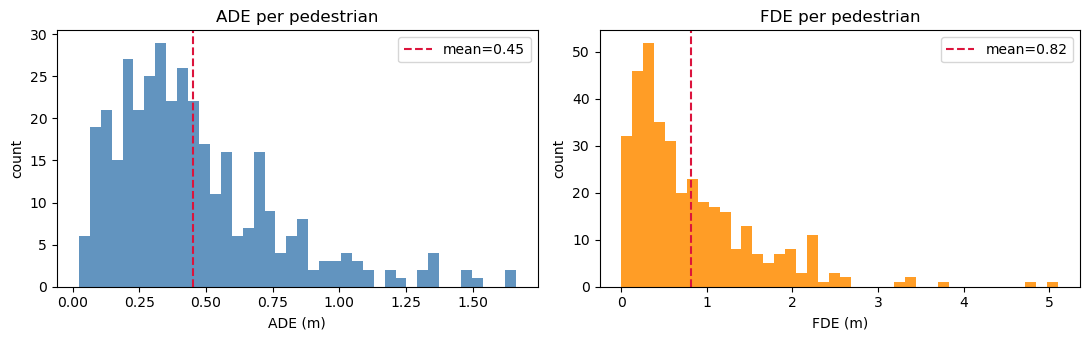

In [17]:
import matplotlib.pyplot as plt

ade_arr = results["ade_per_pedestrian"]
fde_arr = results["fde_per_pedestrian"]
if ETH_RESCALE:
    ade_arr = ade_arr / 0.6
    fde_arr = fde_arr / 0.6

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].hist(ade_arr, bins=40, color="steelblue", alpha=0.85)
axes[0].axvline(ade_arr.mean(), color="crimson", linestyle="--", label=f"mean={ade_arr.mean():.2f}")
axes[0].set_title("ADE per pedestrian")
axes[0].set_xlabel("ADE (m)"); axes[0].set_ylabel("count"); axes[0].legend()

axes[1].hist(fde_arr, bins=40, color="darkorange", alpha=0.85)
axes[1].axvline(fde_arr.mean(), color="crimson", linestyle="--", label=f"mean={fde_arr.mean():.2f}")
axes[1].set_title("FDE per pedestrian")
axes[1].set_xlabel("FDE (m)"); axes[1].set_ylabel("count"); axes[1].legend()

plt.tight_layout()
plt.show()

## Reference numbers from the paper (Best-of-20)

| Scene  | ADE  | FDE  |
|--------|------|------|
| eth    | 0.39 | 0.66 |
| hotel  | 0.13 | 0.22 |
| univ   | 0.22 | 0.45 |
| zara1  | 0.17 | 0.30 |
| zara2  | 0.13 | 0.27 |

With only 20 epochs of training we have much higher losses compared to the authors. 


Mean FDE : 0.82 for eth

Mean ADE : 0.45 for eth


But, the numbers reflect a reduction in losses with more and more epochs of training with augmentation enabled. Due to compute limitations we deduce that since the test errors reduce in the correct direction our implementation of the model is correct.

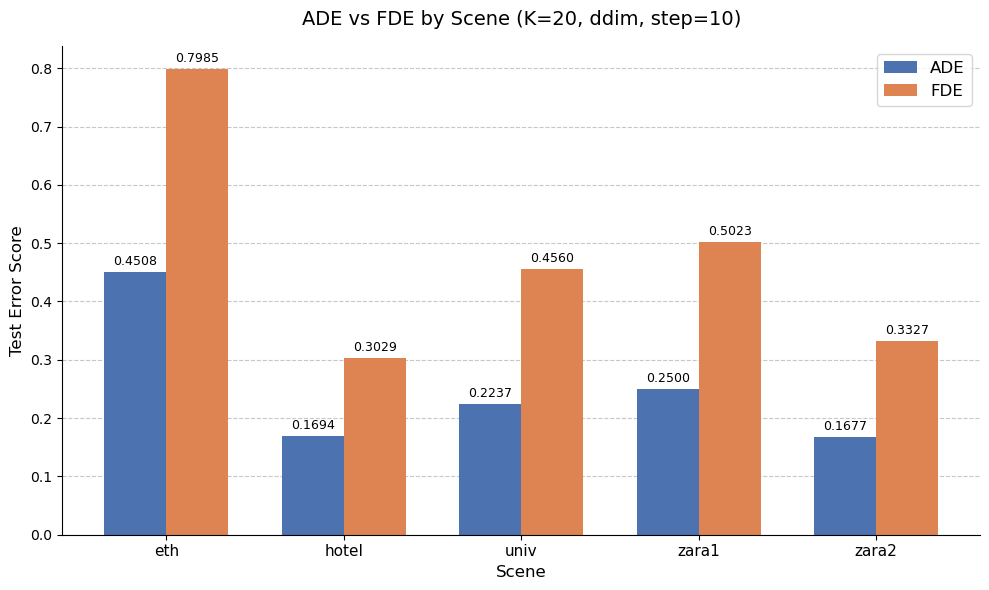

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Prepare the Data
scenes = ['eth', 'hotel', 'univ', 'zara1', 'zara2'] #, 'mean']
ade_scores = [0.4508, 0.1694, 0.2237, 0.2500, 0.1677] #, 0.2523]
fde_scores = [0.7985, 0.3029, 0.4560, 0.5023, 0.3327] #, 0.4785]

# 2. Set up the bar locations and width
x = np.arange(len(scenes))  # the label locations
width = 0.35  # the width of the bars

# 3. Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Plot ADE and FDE bars side by side
rects1 = ax.bar(x - width/2, ade_scores, width, label='ADE', color='#4C72B0')
rects2 = ax.bar(x + width/2, fde_scores, width, label='FDE', color='#DD8452')

# 4. Add labels, title, and formatting
ax.set_ylabel('Test Error Score', fontsize=12)
ax.set_xlabel('Scene', fontsize=12)
ax.set_title('ADE vs FDE by Scene (K=20, ddim, step=10)', fontsize=14, pad=15)
ax.set_xticks(x)
ax.set_xticklabels(scenes, fontsize=11)
ax.legend(fontsize=12)

# Optional: Add the exact data values on top of each bar
ax.bar_label(rects1, padding=3, fmt='%.4f', fontsize=9)
ax.bar_label(rects2, padding=3, fmt='%.4f', fontsize=9)

# 5. Clean up layout and display
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.7) # Add a subtle horizontal grid
ax.set_axisbelow(True) # Put grid lines behind the bars

fig.tight_layout()

# Save the plot as an image file (optional)
# plt.savefig('trajectory_metrics.png', dpi=300)

# Show the plot window
plt.show()

In [ ]:
# Plot training and validation loss curves from the loaded checkpoint
train_loss = ckpt.get("history", [])
val_loss = ckpt.get("val_history", [])

fig, ax = plt.subplots(figsize=(10, 5))

if train_loss:
    ax.plot(train_loss, label="train loss", color="steelblue")
if val_loss:
    ax.plot(val_loss, label="val loss", color="darkorange")

ax.set_title(f"Loss curve: {CHECKPOINT}")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.grid(True, linestyle="--", alpha=0.4)
ax.legend()

plt.tight_layout()
plt.show()